In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Data load karna
data = pd.read_csv('Country-data.csv')

In [4]:
# Basic checks
print("Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())
print("\nDuplicates:", data.duplicated().sum())
data.head()

Shape: (167, 10)

Missing Values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicates: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


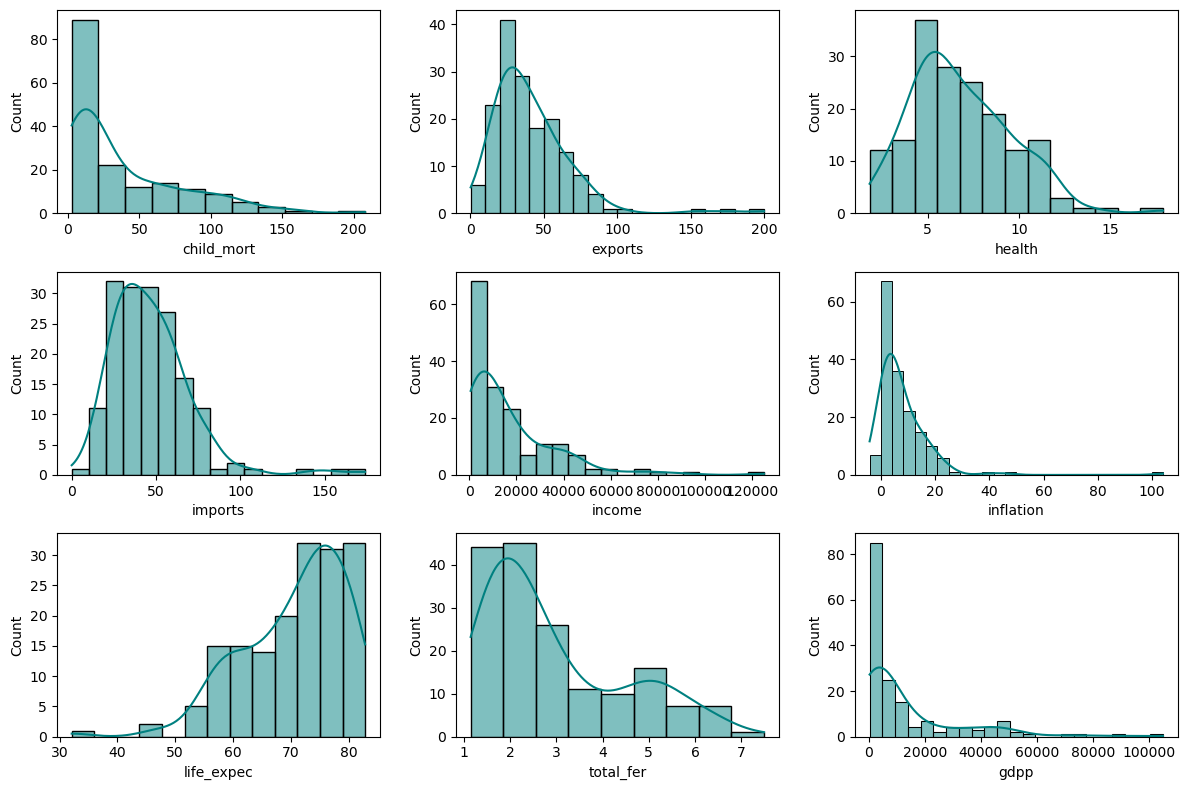

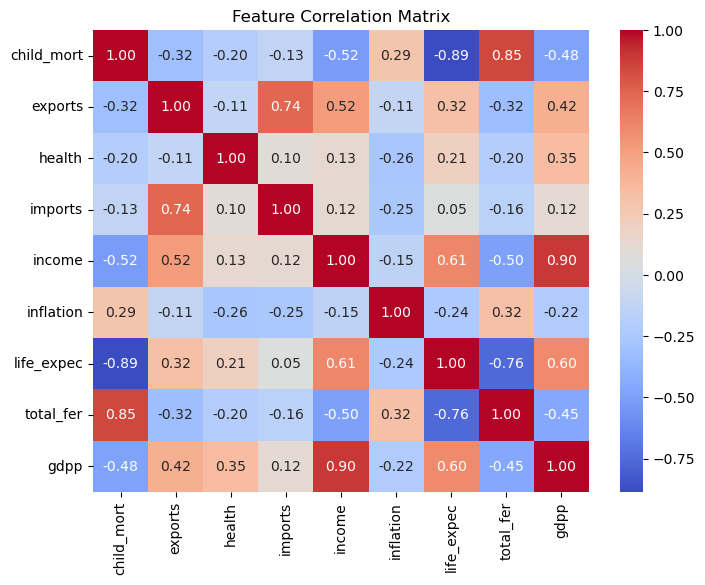

In [5]:
# Numerical features alag karna
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Histograms plot karna
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, color='teal')
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [10]:
# Country column alag save karna
countries = data['country']
X = data.drop(columns=['country'])

skewed_features = ['gdpp', 'income', 'child_mort']
X_transformed = X.copy()
for col in skewed_features:
    X_transformed[col] = np.log1p(X_transformed[col])

# Data standard scale karna
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)

print("Scaled Data Shape:", X_scaled.shape)
print("X_scaled mein bache hue NaN values:", np.isnan(X_scaled).sum())

Scaled Data Shape: (167, 9)
X_scaled mein bache hue NaN values: 0


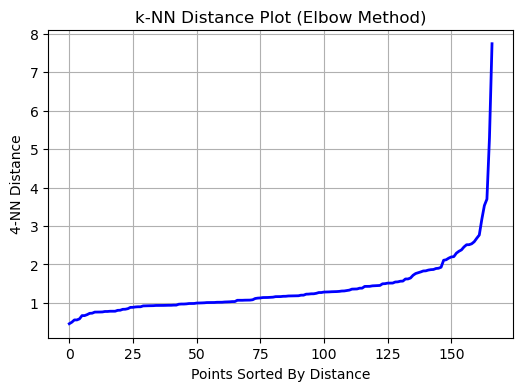

In [11]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# k = min_samples - 1 (5 - 1 = 4)
k = 4
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, indices = nn.kneighbors(X_scaled)

# Distances ko sort karke plot karna
sorted_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(sorted_distances, color='blue', lw=2)
plt.title('k-NN Distance Plot (Elbow Method)')
plt.xlabel('Points Sorted By Distance')
plt.ylabel('4-NN Distance')
plt.grid(True)
plt.show()

In [13]:
# Tuning grid setup
eps_list = [1.0, 1.2, 1.4, 1.6]
min_samples_list = [3, 5, 8]
results = []

for eps in eps_list:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        
        # Clusters ki tadad (noise ko minus kar ke)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # FIXED: Silhouette score ke liye kam se kam 2 clusters (n_clusters >= 2) ka hona zaroori hai
        if n_clusters >= 2:
            score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        else:
            score = np.nan
            
        results.append({
            'Epsilon': eps, 
            'Min_Samples': ms, 
            'Clusters': n_clusters, 
            'Noise': n_noise, 
            'Silhouette': score
        })

# Results table display karna
tuning_table = pd.DataFrame(results)
tuning_table

,Epsilon,Min_Samples,Clusters,Noise,Silhouette
0,1.0,3,5,76,0.347036
1,1.0,5,5,104,0.308152
2,1.0,8,2,139,0.562854
3,1.2,3,3,50,0.223194
4,1.2,5,3,61,0.261697
5,1.2,8,4,81,0.315701
6,1.4,3,1,28,NaN
7,1.4,5,1,33,NaN
8,1.4,8,2,48,0.441445
9,1.6,3,1,21,NaN


In [14]:
# Final Model tuning ke baad (e.g., eps=1.4, min_samples=5)
best_eps, best_ms = 1.4, 5
dbscan = DBSCAN(eps=best_eps, min_samples=best_ms)
data['Cluster'] = dbscan.fit_predict(X_scaled)

# Report summary
print(f"Clusters Found: {len(set(data['Cluster'])) - (1 if -1 in data['Cluster'] else 0)}")
print(f"Noise Points: {list(data['Cluster']).count(-1)}")

# Country groups print karna
for cid in sorted(set(data['Cluster'])):
    c_list = countries[data['Cluster'] == cid].tolist()
    group_name = "Noise Outliers" if cid == -1 else f"Cluster {cid}"
    print(f"\n🟢 {group_name} (Total: {len(c_list)}):\n", c_list)

Clusters Found: 2
Noise Points: 33

🟢 Noise Outliers (Total: 33):
 ['Angola', 'Belarus', 'Botswana', 'Burundi', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Kiribati', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Myanmar', 'Nigeria', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'Solomon Islands', 'South Africa', 'Sudan', 'Timor-Leste', 'Togo', 'Turkmenistan', 'United States', 'Venezuela']

🟢 Cluster 0 (Total: 134):
 ['Afghanistan', 'Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cyprus', 'Czech Repub

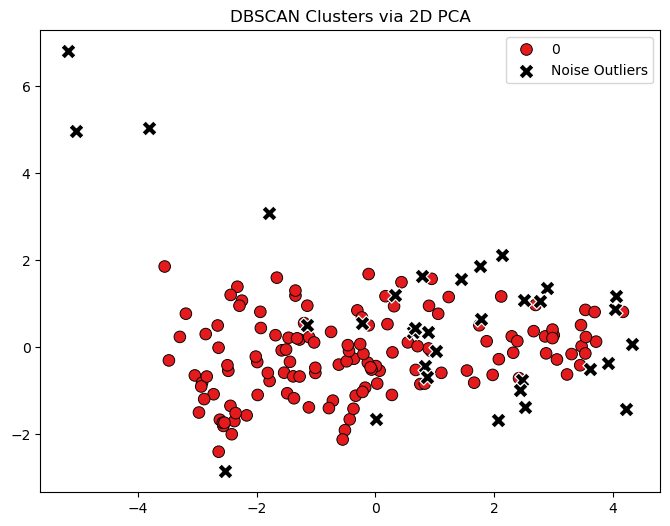

,gdpp,income,child_mort,life_expec
Cluster,,,,
-1,9971.454545,13512.454545,66.566667,63.690909
0,13701.164179,18039.194030,31.301493,72.246269


In [15]:
# 2D PCA Dimensionality Reduction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
# Regular clusters plot karna
sns.scatterplot(
    x=X_pca[data['Cluster'] != -1, 0], y=X_pca[data['Cluster'] != -1, 1], 
    hue=data['Cluster'][data['Cluster'] != -1], palette='Set1', s=70, edgecolors='k'
)
# Outliers ko 'X' plot karna
sns.scatterplot(
    x=X_pca[data['Cluster'] == -1, 0], y=X_pca[data['Cluster'] == -1, 1], 
    color='black', marker='X', s=120, label='Noise Outliers'
)
plt.title('DBSCAN Clusters via 2D PCA')
plt.legend()
plt.show()

# Mean Profile metrics per cluster
cluster_profile = data.groupby('Cluster')[['gdpp', 'income', 'child_mort', 'life_expec']].mean()
cluster_profile

In [18]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. K-Means train aur evaluate karna
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

print("=== CLUSTERING ALGORITHM PERFORMANCE METRICS ===")
print(f"K-Means Silhouette Score: {silhouette_score(X_scaled, km_labels):.3f}")
print(f"K-Means Davies-Bouldin Index: {davies_bouldin_score(X_scaled, km_labels):.3f}")

# 2. DBSCAN ka status check karna (Noise ko nikal kar)
db_labels = data['Cluster'].values
non_noise_mask = db_labels != -1

X_filtered = X_scaled[non_noise_mask]
labels_filtered = db_labels[non_noise_mask]

# Noise ke ilawa kitne unique clusters bache?
unique_clusters_count = len(np.unique(labels_filtered))

if unique_clusters_count >= 2:
    db_sil = silhouette_score(X_filtered, labels_filtered)
    db_db = davies_bouldin_score(X_filtered, labels_filtered)
    print(f"DBSCAN Silhouette Score (Excl Noise): {db_sil:.3f}")
    print(f"DBSCAN Davies-Bouldin Index (Excl Noise): {db_db:.3f}")
else:
    pass

=== CLUSTERING ALGORITHM PERFORMANCE METRICS ===
K-Means Silhouette Score: 0.245
K-Means Davies-Bouldin Index: 1.367


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
